## Task 2: Building a Simple Baseline Model

In this task, you will build and train a classification model from scratch. This will serve as your baseline model against which you can compare results. Create a Jupyter notebook named `baseline.ipynb`, which implements the following steps (you can import the dataset loading from previous steps into this notebook):

> **Hint:** If your initial training runs result in poor accuracy on the test set, find out why this is the case based on the observations made in Task 1. Carefully reconsider your training and final evaluation strategy to address this problem. In particular, reflect on the implementation of the loss function. A conventional loss may not sufficiently penalize misclassifications. Additionally, you can think about complementary strategies.

> **Hint:** Some loss functions have a built-in activation function. In these cases, you do not need a final activation layer in your network. However, when validating the model, you should then apply the activation to your outputs before performing the classification.

### 1. Set up the classification
- Choose one or more metrics to evaluate the success of your classifier.

### 2. Build your initial model
- Build a classifier model with a convolutional part followed by a fully connected part. The convolutional part must have convolutional layers, but you can also include activation, pooling, or batch normalization layers.
- The fully connected part must have fully connected layers and one or more dropout layers.
- Print the initial architecture.
- Print the number of trainable parameters.

### 3. Train your model
- Choose a good loss function for training the model and reasonable starting hyperparameter values.
- Decide which performance metric(s) you will use to evaluate the model and briefly justify your choice.
- Train your initial model on the dataset while monitoring the performance on the validation set.
- Ensure that the model runs without errors and that the training loss decreases smoothly.
- Plot the model history containing its performance at each epoch for both the training and validation sets.

### 4. Hyperparameter tuning
- Typically, hyperparameter tuning is performed. As this requires training multiple models, which is time-consuming, you do not have to complete a full tuning procedure. Nevertheless, make smart choices for your hyperparameters. Furthermore, you can also test different loss functions or optimizers.

### 5. Your final baseline
- Retrain your model using the complete training dataset (including the validation set) with the previously determined optimal set of hyperparameters.
- Plot the training curve.
- Save the model and load it again.
- Evaluate the model on the test dataset and report the performance metric(s) chosen for this problem.
- Plot a few samples from the test dataset (without normalization) together with their predictions and ground-truth labels.
- Perform a ROC–AUC analysis and plot the ROC curve.
- Based on the ROC curve, discuss which classification threshold you would choose and justify your choice.
- Display the confusion matrix based on the considered decision threshold.
- Reflect on the clinical implications of this threshold choice (e.g., prioritizing sensitivity vs. specificity).

---

Discuss the implementation of the baseline model in your report. Include the following:

- **Model architecture:** Describe and discuss your model architecture.
- **Metrics:** Which metrics did you use to evaluate the model? Why are these appropriate, and how do you interpret them based on your results? Also consider the clinical interpretation of the chosen metrics.
- **Training and validation loss:** Which loss function did you choose and why? What conclusions can you draw from the loss curves? Did you observe signs of overfitting? If so, which countermeasures against overfitting did you take or would you suggest?
- **Hint:** If you made any changes based on the hint above, include and motivate them in the sections below.
- **Hyperparameters:** Discuss the chosen hyperparameters.
- **Others:** If you carried out further optimization or experiments, you may include them here as well. For example, did you try other loss functions?
- **Performance:** What conclusions can you draw from the performance on the test set? How does the chosen decision threshold affect the clinical interpretation of the model's predictions?

# 1. Setup

In [28]:
# Set the GPU device
import sys

sys.path.insert(0, "../0_generalcode")
from gpu_helper import settest_torch_gpu

settest_torch_gpu()
device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow , device: cuda
PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow , device: cuda


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)
import os

# 2. Get, load and inspect input data

In [30]:
from pipeline_helper import MyTransform, MyPreprocess

DATA_DIR = "../../data/1_source/"

train_dataset = datasets.ImageFolder(DATA_DIR + "/train", transform=MyTransform())
val_dataset = datasets.ImageFolder(DATA_DIR + "/val", transform=MyPreprocess())
test_dataset = datasets.ImageFolder(DATA_DIR + "/test", transform=MyPreprocess())

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training samples: 750
Validation samples: 159
Test samples: 146
Classes: ['0', '1']


An option we can investigate is dropping the outliers. => use a subset of the train folder + use adjusted statistics from pipeline_helper instead of the defaults
- g_train_no_outliers_mean = 0.6106
- g_train_no_outliers_std = 0.1915

In [ ]:
import pandas as pd
from torch.utils.data import Subset
from pipeline_helper import g_train_no_outliers_mean, g_train_no_outliers_std

# Load image metadata exported from preprocessing notebook
images_info = pd.read_csv(DATA_DIR + "/images_info.csv")


# filter the train folder on outliers we marked in the drop_sample column
def make_filtered_dataset(root, split, transform, info_df, drop_col="drop_sample"):
    """Return an ImageFolder for split, keeping only rows where drop_col == 0."""
    ds = datasets.ImageFolder(os.path.join(root, split), transform=transform)
    keep = set(
        info_df[(info_df["split"] == split) & (info_df[drop_col] == 0)]["filename"]
    )
    valid_idx = [
        i for i, (path, _) in enumerate(ds.samples) if os.path.basename(path) in keep
    ]
    return Subset(ds, valid_idx)


# make a dataset without the outllier and use the corresponding stats for the transformation
train_no_outlier_dataset = make_filtered_dataset(
    DATA_DIR,
    "train",
    MyTransform(tr_mean=g_train_no_outliers_mean, tr_std=g_train_no_outliers_std),
    images_info,
)
train_no_outlier_loader = DataLoader(
    train_no_outlier_dataset, batch_size=32, shuffle=True
)

print(f"Original train   : {len(train_dataset)} samples")
print(f"No-outlier train : {len(train_no_outlier_dataset)} samples")
print(
    f"Removed          : {len(train_dataset) - len(train_no_outlier_dataset)} sample(s)"
)

Original train   : 750 samples
No-outlier train : 742 samples
Removed          : 8 sample(s)


In [32]:
# Count the number of samples per class in the training set
class_counts = np.bincount([label for _, label in train_dataset])
print(f"Healthy: {class_counts[0]}, OA: {class_counts[1]}")

# positive weight to make sure the loss function treats the classes equally (one OA mistake is as bad as 2 healthy mistakes)
# If there are 3x more healthy than OA images, pos_weight = 3.0
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(
    device
)
print(f"pos_weight: {pos_weight.item():.2f}")

Healthy: 500, OA: 250
pos_weight: 2.00


# 3. build the baseline CNN architecture

In [33]:
from model_helper import BaselineCNN

# 4. Train the model

In [34]:
def train_model(
    model, train_loader, val_loader, criteria, optimizer, num_epochs, device
):
    """Train the model and track metrics per epoch."""
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    for epoch in range(num_epochs):
        # Training phase
        model.train()  # Enables dropout and batch norm in training mode
        running_loss = 0.0
        all_preds = []
        all_labels = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device)  # BCE expects float labels

            optimizer.zero_grad()  # Reset gradients from previous step
            outputs = model(images).squeeze(1)  # Forward pass, shape: (batch,)
            loss = criteria(outputs, labels)  # Compute loss
            loss.backward()  # Compute gradients
            optimizer.step()  # Update weights

            running_loss += loss.item() * images.size(0)
            # Apply sigmoid to get probabilities, then threshold at 0.5
            preds = (torch.sigmoid(outputs) >= 0.5).int()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_f1 = f1_score(all_labels, all_preds)

        # Valdation phase
        model.eval()  # Disables dropout, batch norm uses running stats
        running_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():  # No gradient computation needed for validation
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().to(device)
                outputs = model(images).squeeze(1)
                loss = criteria(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) >= 0.5).int()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = running_loss / len(val_loader.dataset)
        val_f1 = f1_score(all_labels, all_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        if (epoch + 1) % 5 == 0:  # Print every 5 epochs to reduce clutter
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {train_loss:.4f}, F1: {train_f1:.4f} | "
                f"Val Loss: {val_loss:.4f}, F1: {val_f1:.4f}"
            )

    return history

In [35]:
# Training the baseline model
model = BaselineCNN(dropout_rate=0.5).to(device)
criteria = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = train_model(
    model, train_loader, val_loader, criteria, optimizer, num_epochs=100, device=device
)

Epoch 5/100 | Train Loss: 0.8363, F1: 0.5656 | Val Loss: 0.8375, F1: 0.6387
Epoch 10/100 | Train Loss: 0.5818, F1: 0.7306 | Val Loss: 0.6642, F1: 0.7667
Epoch 15/100 | Train Loss: 0.5099, F1: 0.7630 | Val Loss: 0.7128, F1: 0.7117
Epoch 20/100 | Train Loss: 0.4628, F1: 0.7939 | Val Loss: 0.3951, F1: 0.8702
Epoch 25/100 | Train Loss: 0.3944, F1: 0.8107 | Val Loss: 0.4320, F1: 0.8814
Epoch 30/100 | Train Loss: 0.3130, F1: 0.8798 | Val Loss: 0.5240, F1: 0.8281
Epoch 35/100 | Train Loss: 0.2973, F1: 0.8760 | Val Loss: 0.4978, F1: 0.8455
Epoch 40/100 | Train Loss: 0.2553, F1: 0.9016 | Val Loss: 0.4298, F1: 0.8618
Epoch 45/100 | Train Loss: 0.3196, F1: 0.8866 | Val Loss: 0.4690, F1: 0.8397
Epoch 50/100 | Train Loss: 0.2024, F1: 0.9173 | Val Loss: 0.5847, F1: 0.8455
Epoch 55/100 | Train Loss: 0.2170, F1: 0.9225 | Val Loss: 0.5139, F1: 0.8760
Epoch 60/100 | Train Loss: 0.2098, F1: 0.9234 | Val Loss: 0.6193, F1: 0.8760
Epoch 65/100 | Train Loss: 0.1985, F1: 0.9267 | Val Loss: 0.5151, F1: 0.8710


In [ ]:
# Training the baseline model without outliers
model = BaselineCNN(dropout_rate=0.5).to(device)
criteria = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history_no_outliers = train_model(
    model,
    train_no_outlier_loader,
    val_loader,
    criteria,
    optimizer,
    num_epochs=100,
    device=device,
)

Epoch 5/100 | Train Loss: 0.8634, F1: 0.5198 | Val Loss: 0.9113, F1: 0.6040
Epoch 10/100 | Train Loss: 0.7071, F1: 0.6286 | Val Loss: 0.6523, F1: 0.7541
Epoch 15/100 | Train Loss: 0.5331, F1: 0.7551 | Val Loss: 0.4645, F1: 0.8345
Epoch 20/100 | Train Loss: 0.4144, F1: 0.8340 | Val Loss: 0.4210, F1: 0.8926
Epoch 25/100 | Train Loss: 0.3832, F1: 0.8343 | Val Loss: 0.5522, F1: 0.7468
Epoch 30/100 | Train Loss: 0.3629, F1: 0.8477 | Val Loss: 0.3677, F1: 0.9032
Epoch 35/100 | Train Loss: 0.2820, F1: 0.8740 | Val Loss: 0.3153, F1: 0.9077
Epoch 40/100 | Train Loss: 0.3339, F1: 0.8560 | Val Loss: 0.3400, F1: 0.8983
Epoch 45/100 | Train Loss: 0.2328, F1: 0.9044 | Val Loss: 0.3586, F1: 0.9091
Epoch 50/100 | Train Loss: 0.3506, F1: 0.8444 | Val Loss: 0.3471, F1: 0.9153
Epoch 55/100 | Train Loss: 0.2328, F1: 0.9002 | Val Loss: 0.3655, F1: 0.9091
Epoch 60/100 | Train Loss: 0.2002, F1: 0.9289 | Val Loss: 0.3281, F1: 0.9291
Epoch 65/100 | Train Loss: 0.2457, F1: 0.8971 | Val Loss: 0.6004, F1: 0.8870


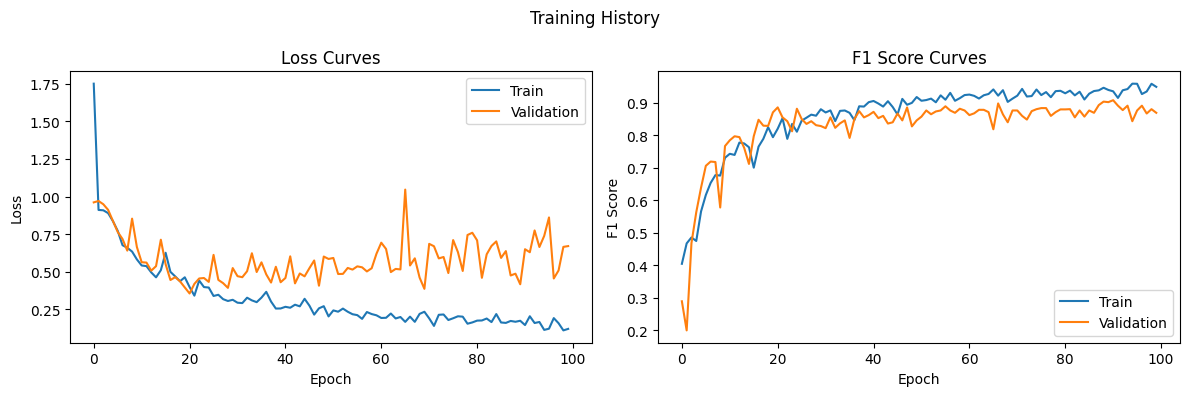

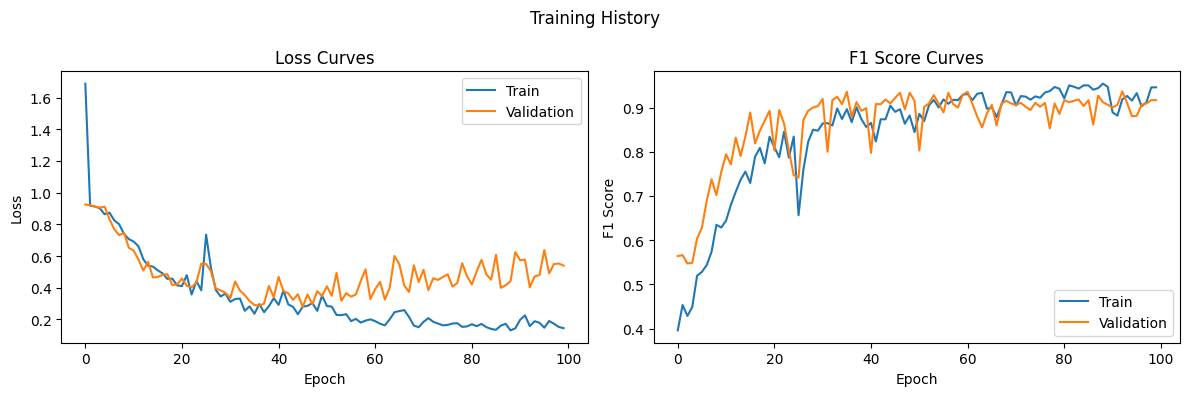

In [37]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curves")
    axes[0].legend()

    axes[1].plot(history["train_f1"], label="Train")
    axes[1].plot(history["val_f1"], label="Validation")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].set_title("F1 Score Curves")
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_history(history)
plot_history(history_no_outliers)

# 5. hyperparameter optimization

In [38]:
# Simple hyperparameter search
param_configs = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
    {"lr": 1e-4, "dropout": 0.3},
    {"lr": 1e-4, "dropout": 0.5},
]

best_val_f1 = 0
best_config = None
results = []

for config in param_configs:
    print(f"\nTesting: lr={config['lr']}, dropout={config['dropout']}")

    # IMPORTANT: new model for each run (fresh random weights)
    model = BaselineCNN(dropout_rate=config["dropout"]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    history = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=30,
        device=device,
    )

    final_val_f1 = history["val_f1"][-1]
    results.append({**config, "val_f1": final_val_f1})

    if final_val_f1 > best_val_f1:
        best_val_f1 = final_val_f1
        best_config = config
        best_history = history

print(f"\nBest config: {best_config} with Val F1: {best_val_f1:.4f}")

# Show all results
for r in results:
    print(f"  lr={r['lr']}, dropout={r['dropout']} → Val F1: {r['val_f1']:.4f}")


Testing: lr=0.001, dropout=0.3
Epoch 5/30 | Train Loss: 0.7015, F1: 0.6198 | Val Loss: 0.6777, F1: 0.7259
Epoch 10/30 | Train Loss: 0.4315, F1: 0.7911 | Val Loss: 0.4385, F1: 0.9153
Epoch 15/30 | Train Loss: 0.3728, F1: 0.7949 | Val Loss: 0.4823, F1: 0.8143
Epoch 20/30 | Train Loss: 0.3466, F1: 0.8394 | Val Loss: 0.5293, F1: 0.8421
Epoch 25/30 | Train Loss: 0.2281, F1: 0.9087 | Val Loss: 0.5249, F1: 0.9060
Epoch 30/30 | Train Loss: 0.2603, F1: 0.8949 | Val Loss: 0.5553, F1: 0.8772

Testing: lr=0.001, dropout=0.5
Epoch 5/30 | Train Loss: 0.8966, F1: 0.5042 | Val Loss: 0.9175, F1: 0.6667
Epoch 10/30 | Train Loss: 0.6050, F1: 0.7102 | Val Loss: 0.7375, F1: 0.7928
Epoch 15/30 | Train Loss: 0.5007, F1: 0.7547 | Val Loss: 0.4717, F1: 0.8571
Epoch 20/30 | Train Loss: 0.4070, F1: 0.7920 | Val Loss: 0.4604, F1: 0.8455
Epoch 25/30 | Train Loss: 0.3463, F1: 0.8339 | Val Loss: 0.4369, F1: 0.8667
Epoch 30/30 | Train Loss: 0.3162, F1: 0.8339 | Val Loss: 0.5401, F1: 0.8696

Testing: lr=0.0001, dropo

# 6. Train the final model based on best hyperparameter config

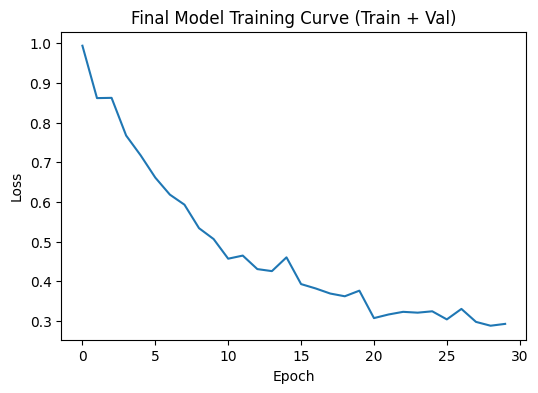

Model saved!
Model loaded successfully!


In [39]:
# Combine train and val for final training
# Create new datasets without augmentation for val portion
full_train_dataset = ConcatDataset([train_dataset, val_dataset])
full_train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

# Fresh model with best hyperparameters
final_model = BaselineCNN(dropout_rate=best_config["dropout"]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(final_model.parameters(), lr=best_config["lr"])

# Train (no validation loader this time — we used all data for training)
final_model.train()
train_losses = []

for epoch in range(30):
    running_loss = 0.0
    for images, labels in full_train_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = final_model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(full_train_loader.dataset)
    train_losses.append(epoch_loss)

# Plot final training curve
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Training Curve (Train + Val)")
plt.show()

# Save and reload
torch.save(final_model.state_dict(), "baseline_model.pth")
print("Model saved!")

loaded_model = BaselineCNN.load(
    "baseline_model.pth", device, dropout_rate=best_config["dropout"]
)
print("Model loaded successfully!")

# 9. Get all predictions and probabilities from final model

In [40]:
loaded_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = loaded_model(images).squeeze(1)
        probs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 10. Visulize AUC, ROC and Confusion matrix

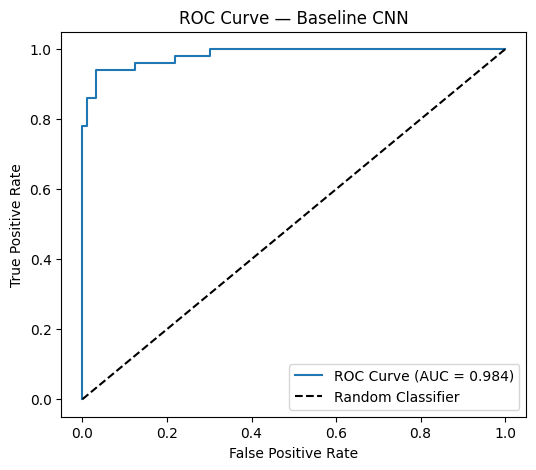

Optimal threshold (Youden's J): 0.464
At this threshold: Sensitivity=0.940, Specificity=0.969


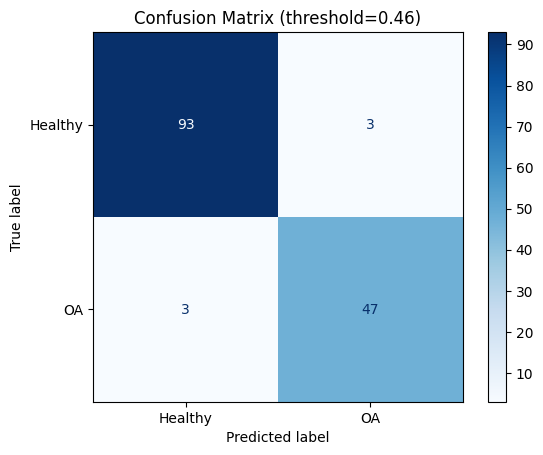

Accuracy: 0.9589
F1 Score: 0.9400


In [41]:
# AUC and ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline CNN")
plt.legend()
plt.show()

# Choose threshold (Youden's J statistic)
# This picks the threshold that maximizes (sensitivity + specificity - 1) so false positives and false negatives are equally not there
# this however assumes that false negatives and positives are equally bad
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (Youden's J): {best_threshold:.3f}")
print(
    f"At this threshold: Sensitivity={tpr[best_idx]:.3f}, Specificity={1-fpr[best_idx]:.3f}"
)

# Confusion Matrix
final_preds = (all_probs >= best_threshold).astype(int)
cm = confusion_matrix(all_labels, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
plt.show()

# Print metrics
print(f"Accuracy: {accuracy_score(all_labels, final_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, final_preds):.4f}")

# 11. inspect predictions

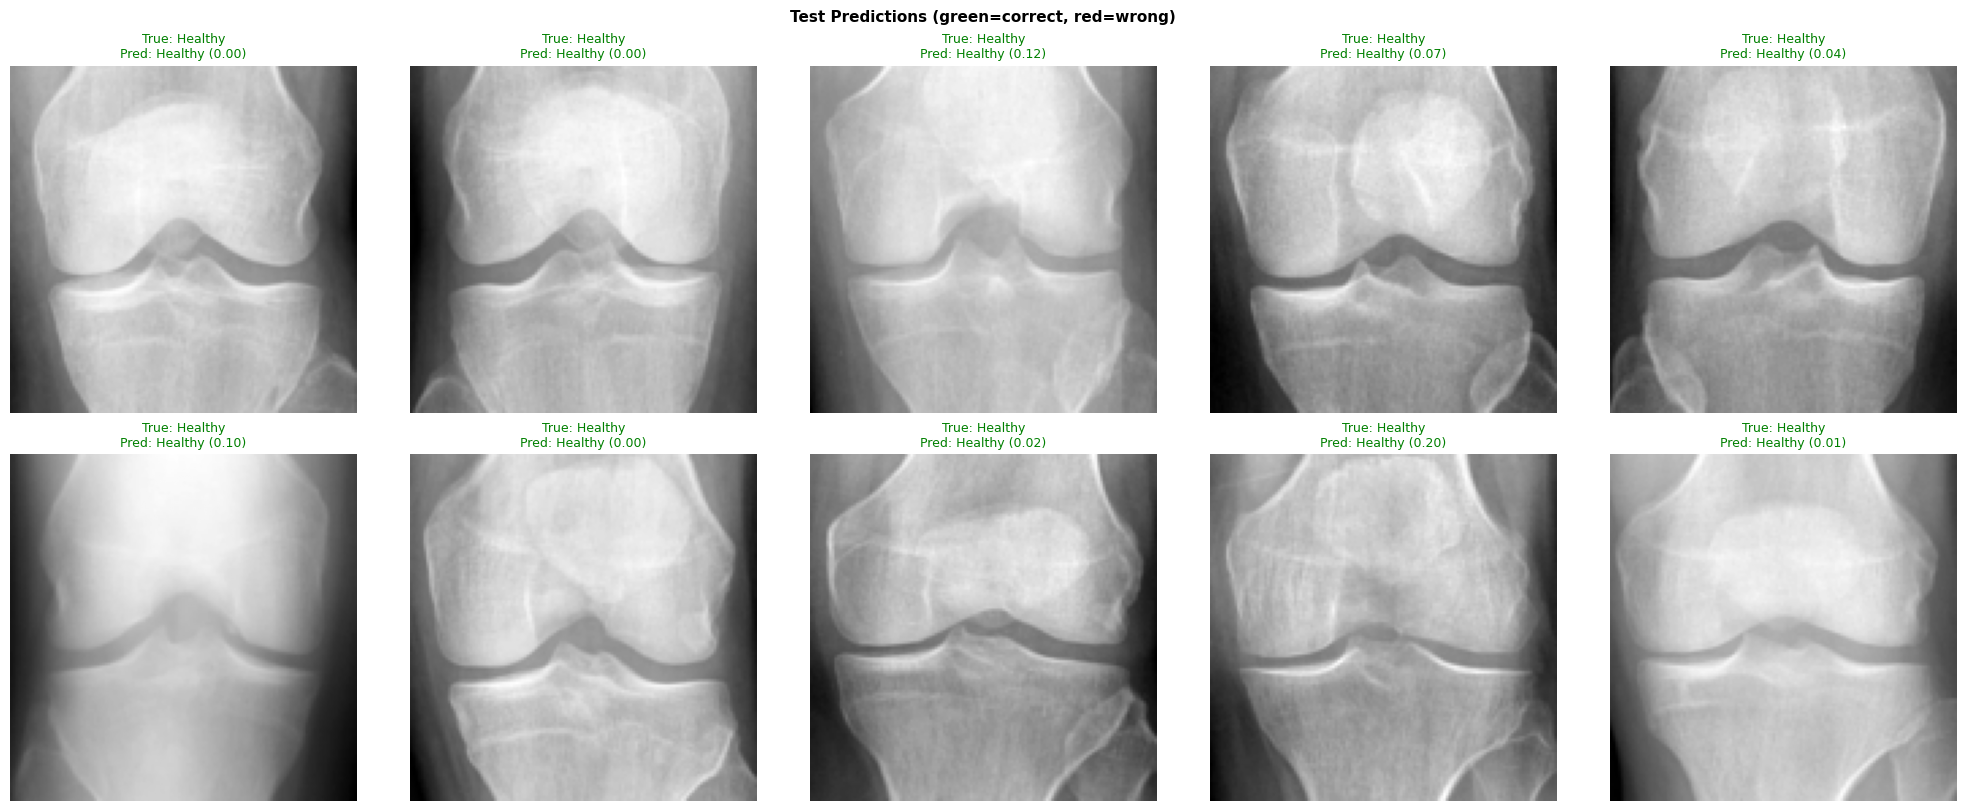

In [43]:
from img_helper import show_images
from pipeline_helper import MyToTensor

display_dataset = datasets.ImageFolder(DATA_DIR + "/test", transform=MyToTensor())
CLASS_NAMES = ["Healthy", "OA"]

all_preds_arr = (all_probs >= best_threshold).astype(int)

show_images(
    list(range(10)),
    display_dataset,
    all_labels,
    all_preds_arr,
    all_probs,
    CLASS_NAMES,
    title="Test Predictions (green=correct, red=wrong)",
)

to do's:
- show normal BCE comparison with BCE loss with a possible explanaition on why one might be better than the other
- determine what statistics to use or not use
- add sensitivity (not missing any OA) and specificity